Задание 1. Используя исторические данные на листе «Timeseries» (см. Задания_1_2.xlsx), построить модель временного ряда.  Спрогнозировать  ежедневное поведение ряда в следующие 3 мес.  Пояснить выбор метода прогнозирования. Привести оценки качества прогноза.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as sps
import statsmodels.api as sm

In [2]:
data = pd.read_excel("З†§†≠®п_1_2.xlsx")

data.head()

,Date,series1
0,2015-01-01,1006.699649
1,2015-01-02,3197.751826
2,2015-01-03,3217.491035
3,2015-01-04,2151.573759
4,2015-01-05,4243.929892


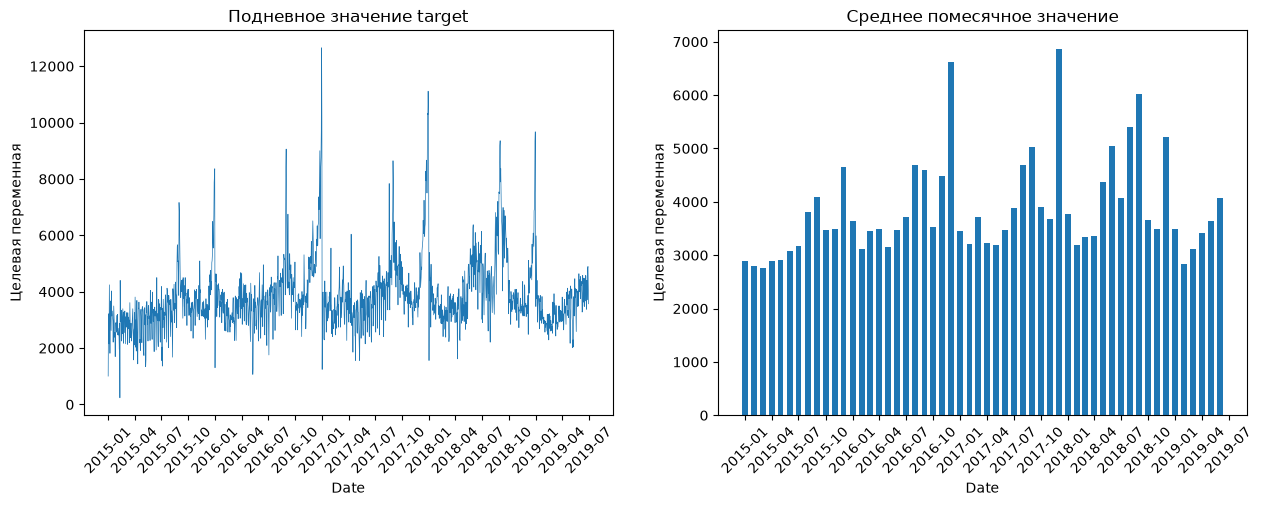

In [3]:
import matplotlib.dates as mdates

data['Date'] = pd.to_datetime(data["Date"])
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

# Строим график целевой переменной
ax[0].plot(data["Date"], data["series1"],
          label="Временной ряд",
          linewidth=0.5)
ax[0].xaxis.set_major_locator(
    mdates.MonthLocator(bymonth=[1, 4, 7, 10])
)
ax[0].xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

ax[0].set_xlabel("Date")
ax[0].set_ylabel("Целевая переменная")
ax[0].tick_params(axis='x', labelrotation=45)
ax[0].set_title("Подневное значение target")

# Строим график среднего по месяцам
date_month = (
    data.groupby(data["Date"].dt.to_period("M"))["series1"].mean()
)

dates = date_month.index.to_timestamp()

ax[1].bar(dates, date_month, width=20)
ax[1].xaxis.set_major_locator(
    mdates.MonthLocator(bymonth=[1, 4, 7, 10])
)

ax[1].set_title("Среднее помесячное значение")


plt.xticks(rotation=45)

plt.xlabel("Date")
plt.ylabel("Целевая переменная")
plt.show()

In [4]:
quartal_data= (
    data.groupby(data["Date"].dt.to_period("Y"))["series1"].mean()
)
quartal_data

Date
2015    3338.152221
2016    4001.275691
2017    4034.640199
2018    4253.069417
2019    3436.258178
Freq: Y-DEC, Name: series1, dtype: float64

По графику видно, что у ряда есть сезонность и меняется средний уровень. В 2015 году среднее было около 3338, в 2016 — 4001, в 2017 — 4035, в 2018 — 4253. За 2019 год есть только полгода, поэтому напрямую сравнивать его с остальными нельзя.

На помесячном графике сезонность видна лучше: во второй половине года значения растут, а в январе падают. При этом высота пиков от года к году разная. На дневном графике также есть отдельные резкие всплески и падения.

Поэтому дальше будем учитывать тренд и сезонность.

In [5]:
data.tail()

,Date,series1
1637,2019-06-26,4007.059387
1638,2019-06-27,4836.106157
1639,2019-06-28,4895.323783
1640,2019-06-29,4086.016222
1641,2019-06-30,3572.796793


Последняя дата в данных — 30 июня 2019 года. Нужно получить ежедневный прогноз на июль, август и сентябрь.

Проверим, связан ли target с днём недели, если уже учесть месяц и тренд. Для этого возьмём логарифм ряда и построим регрессию с линейным и квадратичным трендом, месяцем и днём недели.

Для стандартных ошибок используем HAC с $L=14$, чтобы учесть возможную гетероскедастичность и зависимость остатков.

In [6]:
import statsmodels.formula.api as smf
data["month"] = data["Date"].dt.month
data["week"] = data["Date"].dt.weekday
data['t'] = (
    data["Date"] - data["Date"].min()
).dt.days / 365.25
L = 14
m1 = smf.ols(
    "np.log(series1) ~ t + I(t**2) + C(month) + C(week)",
    data=data
).fit(
    cov_type="HAC",
    cov_kwds={"maxlags": L}
)

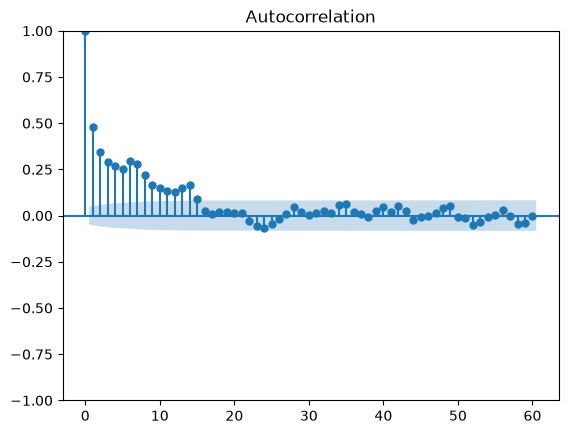

In [7]:
from statsmodels.graphics.tsaplots import plot_acf

plot_acf(m1.resid, lags=60)
plt.show()

Посмотрим на ACF остатков. Она нужна, чтобы оценить, осталась ли зависимость между соседними наблюдениями. Выход за доверительную полосу указывает на возможную автокорреляцию.

Для HAC пока оставим $L=14$, то есть две недели. Сам по себе график не доказывает, что это лучший выбор. Ещё проверим, меняется ли разброс остатков.

LM statistic: 44.10204114423113
LM p-value: 0.0009141401504478429
F statistic: 2.356171491937576
F p-value: 0.0008334347535708609


<IPython.core.display.Math object>

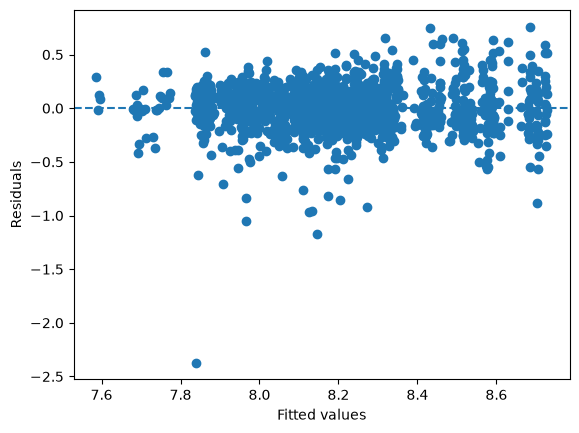

In [7]:
plt.scatter(m1.fittedvalues, m1.resid)
plt.axhline(0, linestyle="--")
plt.xlabel("Fitted values")
plt.ylabel("Residuals")
from statsmodels.stats.diagnostic import het_breuschpagan

bp = het_breuschpagan(m1.resid, m1.model.exog)
print("LM statistic:", bp[0])
print("LM p-value:", bp[1])
print("F statistic:", bp[2])
print("F p-value:", bp[3])

from IPython.display import display, Math

r2 = bp[0] / len(data)
display(Math(rf"R^2 = {100 * r2:.2f}\%"))
plt.show()

В тесте Бройша — Пагана получили $LM\approx44.1$ и $p\approx0.00091$. При уровне значимости $5\%$ гипотеза о постоянной дисперсии отвергается. При этом во вспомогательной регрессии

$$
R^2=\frac{LM}{n}=\frac{44.1}{1642}\approx0.0269.
$$

То есть она объясняет около $2.7\%$ разброса квадратов остатков. Из-за автокорреляции обычный $p$-value этого теста нужно трактовать осторожно.

ACF всё равно можно использовать для просмотра зависимости остатков, но её доверительные полосы здесь скорее ориентир. Для проверки коэффициентов оставим HAC-ошибки.

In [8]:
m1.wald_test_terms()

/Users/stiv/Desktop/AnalystCaces/.venv/lib/python3.13/site-packages/statsmodels/base/model.py:1912: FutureWarning: The behavior of wald_test will change after 0.14 to returning scalar test statistic values. To get the future behavior now, set scalar to True. To silence this message while retaining the legacy behavior, set scalar to False.
  warnings.warn(


<class 'statsmodels.stats.contrast.WaldTestResults'>
                             chi2                  P>chi2  df constraint
Intercept   [[45603.20900040643]]                     0.0              1
C(month)   [[144.54627114532713]]  1.9329566070639354e-25             11
C(week)    [[343.12945486484034]]   4.605472937839788e-71              6
t            [[44.2049588371682]]   2.957311846592413e-11              1
I(t ** 2)   [[22.70060455239254]]  1.8930830049748344e-06              1

По тестам Вальда месяц и день недели значимы совместно внутри своих групп. Линейный и квадратичный тренды тоже значимы: во всех случаях $p<0.05$.

Значит, в этой модели есть основания оставить и сезонность, и тренд.

Сначала возьмём модель

$$
\log y_t=\beta_0+\beta_1t+\beta_2t^2
+\alpha_{m(t)}+\gamma_{w(t)}+\varepsilon_t,
$$

где $t$ — время в годах от начала ряда, $\alpha_{m(t)}$ — эффект месяца, а $\gamma_{w(t)}$ — эффект дня недели. Для одного месяца и одного дня недели эффект принимается равным нулю.

Сравним её с простым прогнозом: значением ряда 364 дня назад. Такой сдвиг сохраняет день недели. Затем попробуем гармоники и модель с зависимыми остатками.

Качество проверим на июле — сентябре 2016, 2017 и 2018 годов. Каждый раз обучаемся только на данных до 1 июля соответствующего года. Сравнивать будем по MAE, RMSE и MAPE.

In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

results = []
for year_test in [2016, 2017, 2018]:

    test_start = pd.Timestamp(f"{year_test}-07-01")
    test_end = pd.Timestamp(f"{year_test}-09-30")

    train = data[(data["Date"] < test_start)].copy()

    test = data[
        (data["Date"] >= test_start) & (data["Date"] <= test_end)
    ]

    model = smf.ols(
        formula="np.log(series1) ~ t + I(t**2) + C(month) + C(week)",
        data=train
    ).fit(
        cov_kwds={"maxlags" : 14},
        cov_type="HAC"
    )

    pred_log = model.predict(test)
    pred = np.exp(pred_log)

    y = test["series1"]

    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    mape = np.mean(np.abs((y - pred) / y)) * 100

    results.append({
        "year": year_test,
        "MAE": mae,
        "MAPE": mape,
        "RMSE": rmse
    })


results = pd.DataFrame(results)
results


,year,MAE,MAPE,RMSE
0,2016,660.159832,13.725771,1019.487584
1,2017,634.620812,12.651408,959.669490
2,2018,900.175324,16.428044,1249.882315


In [11]:
results = []

for year_test in [2016, 2017, 2018]:
    test_start = pd.Timestamp(f"{year_test}-07-01")
    test_end = pd.Timestamp(f"{year_test}-09-30")

    test = data[(data["Date"] <= test_end) & (data["Date"] >= test_start)].copy()
    train = data[data["Date"] < test_start].copy()

    history = train.set_index("Date")["series1"]
    previous_dates = test['Date'] - pd.Timedelta(days=364)

    y = test['series1'].to_numpy()
    pred = history.reindex(previous_dates).to_numpy()

    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    mape = np.mean(np.abs((y - pred) / y)) * 100
    
    results.append({
        "year": year_test,
        "MAE": mae,
        "MAPE": mape,
        "RMSE": rmse
    })

results = pd.DataFrame(results)
results

,year,MAE,MAPE,RMSE
0,2016,706.749498,15.898895,917.520161
1,2017,576.299074,12.394887,802.153710
2,2018,859.728366,15.612821,1131.843323


Прогноз по значению 364 дня назад оказался сопоставим с регрессией. В 2016 году у регрессии ниже MAE и MAPE, но выше RMSE. В 2017 и 2018 годах простой прогноз лучше по всем трём метрикам.

Пока регрессия не даёт устойчивого улучшения. Попробуем описать сезонность через гармоники.

Заменим месяцы и дни недели на синусы и косинусы. Для годовой сезонности возьмём 10 гармоник, для недельной — 3.

Пусть $d$ — число дней от начала ряда, а $t=d/365.25$. Тогда модель имеет вид

$$
\log y_d=\beta_0+\beta_1t+\beta_2t^2+S_{\text{год}}(d)+S_{\text{нед}}(d)+u_d,
$$

где

$$
S_{\text{год}}(d)=\sum_{k=1}^{10}\left[
 a_k\sin\left(\frac{2\pi kd}{365.25}\right)
+b_k\cos\left(\frac{2\pi kd}{365.25}\right)
\right],
$$

$$
S_{\text{нед}}(d)=\sum_{k=1}^{3}\left[
 c_k\sin\left(\frac{2\pi kd}{7}\right)
+e_k\cos\left(\frac{2\pi kd}{7}\right)
\right].
$$

Сначала оценим обычную регрессию и посмотрим ACF и PACF остатков. После этого попробуем учесть зависимость в $u_d$ через SARIMAX.

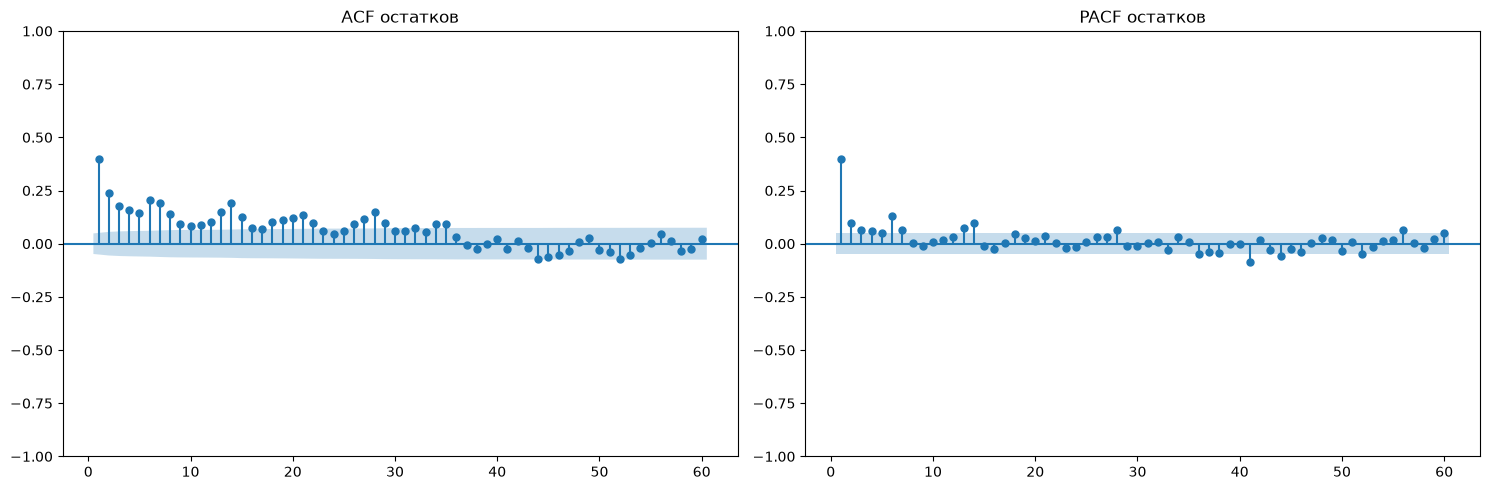

In [ ]:
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf

df = data.copy()
df["t_days"] = (
    df["Date"] - df["Date"].min()
).dt.days

K_year = 10

features = []

for k in range(1, K_year + 1):
    df[f"year_sin_{k}"] = np.sin(
        2 * np.pi * k * df["t_days"] / 365.25
    )
    df[f"year_cos_{k}"] = np.cos(
        2 * np.pi * k * df["t_days"] / 365.25
    )
    features.append(f"year_sin_{k}")
    features.append(f"year_cos_{k}")

K_week = 3

for k in range(1, K_week + 1):
    df[f"week_sin_{k}"] = np.sin(
        2 * np.pi * k * df["t_days"] / 7
    )
    df[f"week_cos_{k}"] = np.cos(
        2 * np.pi * k * df["t_days"] / 7
    )
    features.append(f"week_sin_{k}")
    features.append(f"week_cos_{k}")

features.append("t")
features.append("I(t**2)")

regression = smf.ols(
    "np.log(series1) ~ " + " + ".join(features),
    data=df
).fit()

residuals = regression.resid

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

plot_acf(
    residuals,
    lags=60,
    zero=False,
    ax=axes[0]
)

plot_pacf(
    residuals,
    lags=60,
    zero=False,
    method="ywm",
    ax=axes[1]
)

axes[0].set_title("ACF остатков")
axes[1].set_title("PACF остатков")

plt.tight_layout()
plt.show()

In [30]:
results = []

for year_test in [2016, 2017, 2018]:
    test_start = pd.Timestamp(f"{year_test}-07-01")
    test_end = pd.Timestamp(f"{year_test}-09-30")

    test = df[(df["Date"] <= test_end) & (df["Date"] >= test_start)].copy()
    train = df[df["Date"] < test_start].copy()

    regression = smf.ols(
        "np.log(series1) ~ " + " + ".join(features),
        data=train
    ).fit()

    y = test['series1']
    pred_log = regression.predict(test)
    pred = np.exp(pred_log)

    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    mape = np.mean(np.abs((y - pred) / y)) * 100
    
    results.append({
        "year": year_test,
        "MAE": mae,
        "MAPE": mape,
        "RMSE": rmse
    })

results = pd.DataFrame(results)
results

,year,MAE,MAPE,RMSE
0,2016,673.600745,14.651105,908.767739
1,2017,575.412015,11.807031,819.877685
2,2018,684.782558,12.581677,961.770064


У регрессии с гармониками MAE и MAPE ниже, чем у простого прогноза, во всех трёх годах. По RMSE она лучше в 2016 и 2018 годах, но немного хуже в 2017: примерно 820 против 802.

Теперь добавим зависимость остатков. Возьмём SARIMAX с порядком $(1,0,1)$ и сезонным порядком $(1,0,0,7)$. Тренд и гармоники оставим внешними признаками.

In [31]:
df["t2"] = df["t"] ** 2

fourier_columns = [
    column
    for column in df.columns
    if column.startswith((
        "year_sin_",
        "year_cos_",
        "week_sin_",
        "week_cos_"
    ))
]

exog_columns = [
    "t",
    "t2"
] + fourier_columns

results = []

from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.preprocessing import StandardScaler

for year_test in [2016, 2017, 2018]:
    test_start = pd.Timestamp(f"{year_test}-07-01")
    test_end = pd.Timestamp(f"{year_test}-09-30")

    test = df[(df["Date"] <= test_end) & (df["Date"] >= test_start)].copy()
    train = df[df["Date"] < test_start].copy()

    X_train = train[exog_columns]
    X_test = test[exog_columns]

    scaler = StandardScaler()

    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    Y_train = np.log(
        train["series1"].to_numpy()
    )

    model = SARIMAX(
        endog=Y_train,
        exog=X_train_scaled,

        order=(1,0,1),
        seasonal_order=(1,0,0,7),

        trend="c",

        enforce_stationarity=False,
        enforce_invertibility=False
    )

    fitted_model = model.fit(
        disp=False,
        maxiter=1000,
        method="lbfgs"
    )

    converged = fitted_model.mle_retvals["converged"]

    print(
        year_test,
        "converged:",
        converged
    )

    if not converged:
        raise RuntimeError(
            f"SARIMAX не сошёлся для {year_test} года"
        )

    forecast = fitted_model.get_forecast(
        steps=len(test),
        exog=X_test_scaled
    )

    pred_log = forecast.predicted_mean



    y = test['series1']
    pred = np.exp(pred_log)

    mae = mean_absolute_error(y, pred)
    rmse = np.sqrt(mean_squared_error(y, pred))
    mape = np.mean(np.abs((y - pred) / y)) * 100
    
    results.append({
        "year": year_test,
        "MAE": mae,
        "MAPE": mape,
        "RMSE": rmse
    })

results = pd.DataFrame(results)
results

2016 converged: True
2017 converged: True
2018 converged: True


,year,MAE,MAPE,RMSE
0,2016,509.943760,11.178527,743.570280
1,2017,552.357029,11.325617,796.797885
2,2018,696.776733,12.877707,973.775898


SARIMAX улучшил MAE, MAPE и RMSE относительно регрессии с гармониками в 2016 и 2017 годах. В 2018 году результат немного хуже. Средняя MAPE по трём проверкам получилась около $11.79\%$, у регрессии с гармониками — $13.01\%$, у простого прогноза — $14.64\%$.

Для итогового прогноза выберем SARIMAX: в среднем на этих проверках он оказался лучше. Обучим его на всей доступной истории. Прогноз логарифма вернём в исходную шкалу:

$$
\widehat y_d=\exp\bigl(\widehat{\log y_d}\bigr).
$$

Поправку на смещение при таком переходе здесь не используем.

In [ ]:
last_date = data["Date"].max()

future_dates = pd.date_range(
    start=last_date + pd.Timedelta(days=1),
    periods=90,
    freq="D"
)

future_df = pd.DataFrame({
    "Date": future_dates,
    "series1": np.nan
})

df_extended = pd.concat(
    [data[["Date", "series1"]], future_df],
    ignore_index=True
)

In [38]:
df_extended.tail()

,Date,series1
1727,2019-09-24,NaN
1728,2019-09-25,NaN
1729,2019-09-26,NaN
1730,2019-09-27,NaN
1731,2019-09-28,NaN


In [39]:
df_extended["month"] = df_extended["Date"].dt.month
df_extended["week"] = df_extended["Date"].dt.weekday
df_extended['t'] = (
    df_extended["Date"] - df_extended["Date"].min()
).dt.days / 365.25

In [42]:
df = df_extended.copy()
df["t_days"] = (
    df["Date"] - df["Date"].min()
).dt.days

K_year = 10

for k in range(1, K_year + 1):
    df[f"year_sin_{k}"] = np.sin(
        2 * np.pi * k * df["t_days"] / 365.25
    )
    df[f"year_cos_{k}"] = np.cos(
        2 * np.pi * k * df["t_days"] / 365.25
    )

K_week = 3

for k in range(1, K_week + 1):
    df[f"week_sin_{k}"] = np.sin(
        2 * np.pi * k * df["t_days"] / 7
    )
    df[f"week_cos_{k}"] = np.cos(
        2 * np.pi * k * df["t_days"] / 7
    )

df["t2"] = df["t"]**2



In [43]:
test = df[df["Date"] > last_date]
train = df[df["Date"] <= last_date]

X_train = train[exog_columns]
X_test = test[exog_columns]
Y_train = np.log(
    train["series1"]
).to_numpy()

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = SARIMAX(
        endog=Y_train,
        exog=X_train_scaled,

        order=(1,0,1),
        seasonal_order=(1,0,0,7),

        trend="c",

        enforce_stationarity=False,
        enforce_invertibility=False
    )

fitted_model = model.fit(
        disp=False,
        maxiter=1000,
        method="lbfgs"
    )



In [46]:
forecast = fitted_model.get_forecast(
        steps=len(test),
        exog=X_test_scaled
    )

pred_log = forecast.predicted_mean

preds = np.exp(pred_log)

In [ ]:
final_df = df[["Date", "series1"]]

future_mask = (
    final_df["Date"] > last_date
)

final_df.loc[
    future_mask,
    "series1"
] = preds


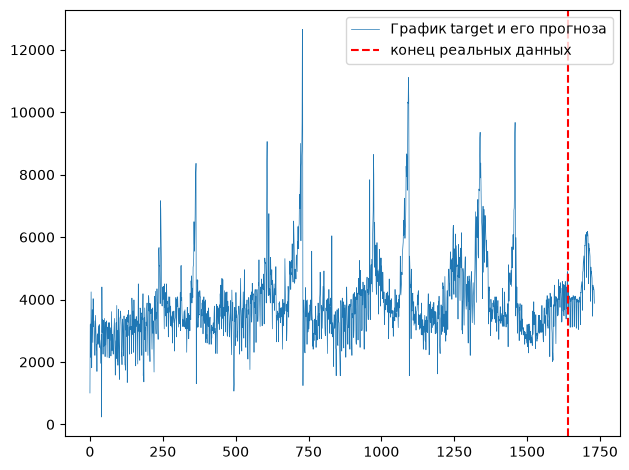

In [56]:
plt.plot(
    np.arange(len(final_df)),
    final_df["series1"],
    label="График target и его прогноза",
    linewidth=0.5
)
plt.axvline(len(final_df) - sum(future_mask), label="конец реальных данных",
            color="red", linestyle="--")
plt.legend()
plt.tight_layout()
plt.show()

В текущем коде прогноз построен на 90 дней: с 1 июля по 28 сентября 2019 года. Для трёх полных месяцев нужно 92 дня, поэтому 29 и 30 сентября здесь пока не охвачены.

Качество оценено на прошлых периодах. Фактических значений за прогнозируемые даты в данных нет, поэтому проверить ошибку именно этого прогноза пока нельзя.